<a href="https://colab.research.google.com/github/Vansh-Rajderkar5901/OIBSIP/blob/main/VanshRajderkar_Project2Level1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [31]:
df = pd.read_csv("ifood_df.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2205, 39)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [33]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [34]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds       

In [35]:
# Remove duplicate rows if any
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2021, 39)


In [36]:
# Drop columns that do not add useful value for segmentation
columns_to_drop = ["Z_CostContact", "Z_Revenue"]

df = df.drop(columns=columns_to_drop)

print("Remaining Columns:", df.shape[1])

Remaining Columns: 37


In [37]:
# Check basic statistics for important numerical columns
df[["Income", "Age", "MntTotal", "Recency"]].describe()

,Income,Age,MntTotal,Recency
count,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,51.117269,563.789213,48.880752
std,20713.046401,11.667616,576.775749,28.950917
min,1730.000000,24.000000,4.000000,0.000000
25%,35416.000000,43.000000,55.000000,24.000000
50%,51412.000000,50.000000,343.000000,49.000000
75%,68274.000000,61.000000,964.000000,74.000000
max,113734.000000,80.000000,2491.000000,99.000000


In [38]:
# Total number of purchases made by customer
df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

# Total children at home
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Average spending per purchase
df["Avg_Spend_Per_Purchase"] = df["MntTotal"] / (df["Total_Purchases"] + 1)

# Total campaign acceptance rate
df["Campaign_Acceptance_Rate"] = df["AcceptedCmpOverall"] / 5

# Total product spending from individual product categories
df["Product_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Purchases,Total_Children,Avg_Spend_Per_Purchase,Campaign_Acceptance_Rate,Product_Spending
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,1529,1441,0,22,0,66.478261,0.0,1617
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,21,15,0,4,2,4.200000,0.0,27
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,734,692,0,20,0,34.952381,0.0,776
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,48,43,0,6,1,6.857143,0.0,53
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,1,407,392,0,14,1,27.133333,0.0,422


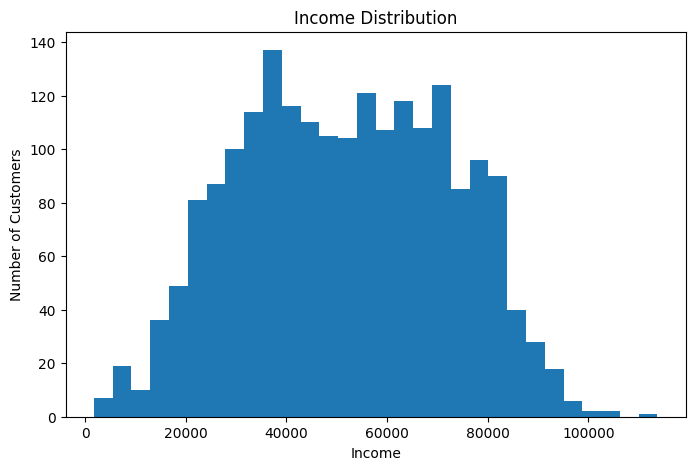

In [39]:
plt.figure(figsize=(8,5))
plt.hist(df["Income"], bins=30)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()

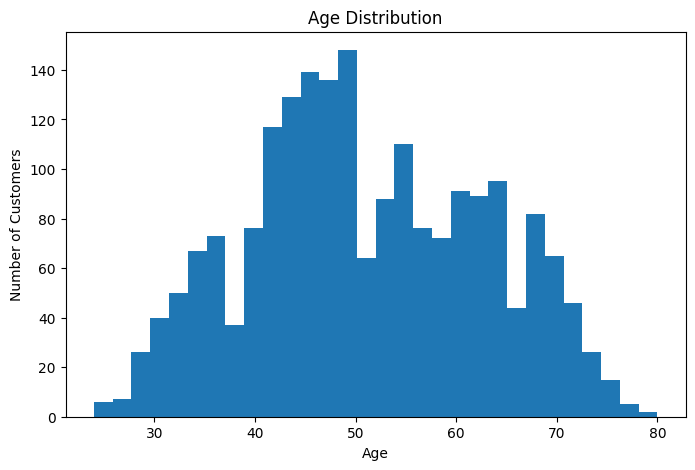

In [40]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

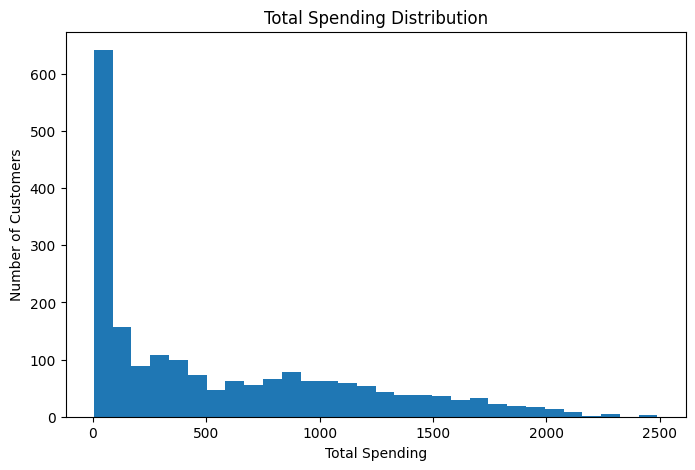

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df["MntTotal"], bins=30)
plt.title("Total Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

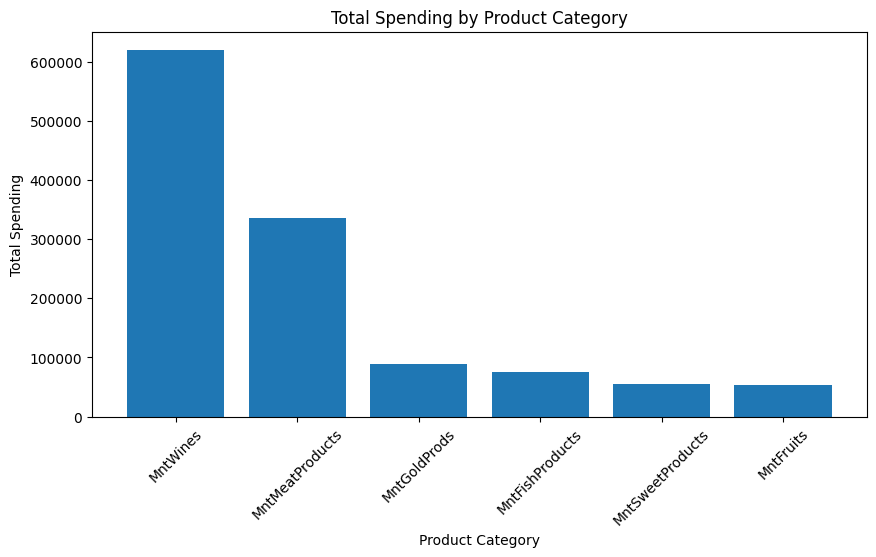

In [43]:
product_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

product_spending = df[product_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(product_spending.index, product_spending.values)
plt.title("Total Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.show()

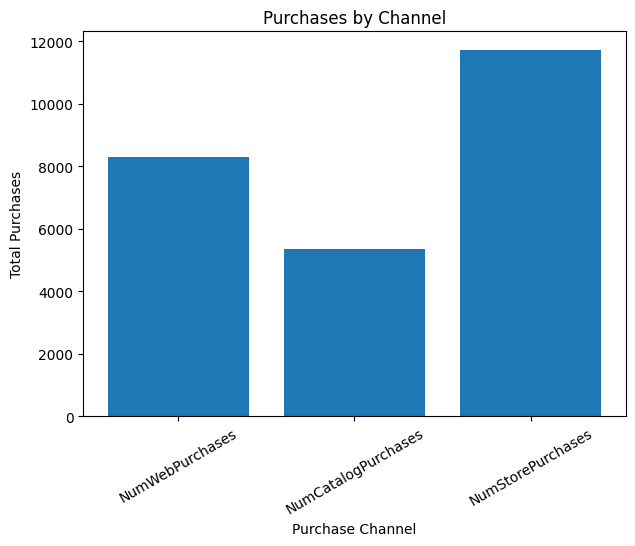

In [44]:
purchase_channels = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

channel_total = df[purchase_channels].sum()

plt.figure(figsize=(7,5))
plt.bar(channel_total.index, channel_total.values)
plt.title("Purchases by Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Total Purchases")
plt.xticks(rotation=30)
plt.show()

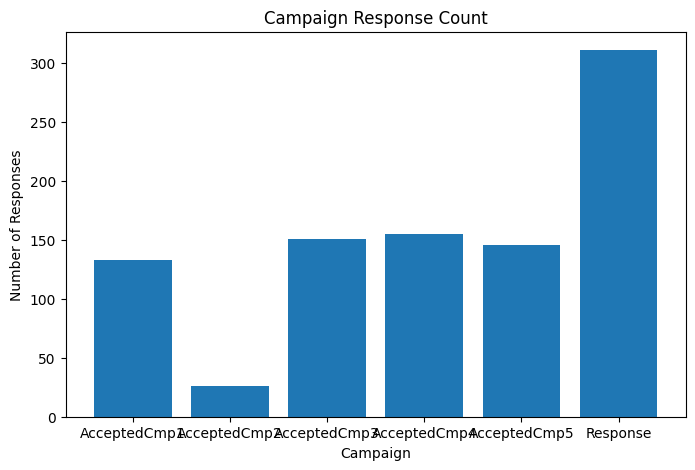

In [45]:
campaign_cols = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5", "Response"
]

campaign_response = df[campaign_cols].sum()

plt.figure(figsize=(8,5))
plt.bar(campaign_response.index, campaign_response.values)
plt.title("Campaign Response Count")
plt.xlabel("Campaign")
plt.ylabel("Number of Responses")
plt.show()

In [46]:
features = [
    "Income",
    "Age",
    "Recency",
    "Customer_Days",
    "MntTotal",
    "MntRegularProds",
    "Product_Spending",
    "Total_Purchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Total_Children",
    "Avg_Spend_Per_Purchase",
    "AcceptedCmpOverall",
    "Campaign_Acceptance_Rate"
]

X = df[features]

X.head()

,Income,Age,Recency,Customer_Days,MntTotal,MntRegularProds,Product_Spending,Total_Purchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Children,Avg_Spend_Per_Purchase,AcceptedCmpOverall,Campaign_Acceptance_Rate
0,58138.0,63,58,2822,1529,1441,1617,22,8,10,4,7,0,66.478261,0,0.0
1,46344.0,66,38,2272,21,15,27,4,1,1,2,5,2,4.200000,0,0.0
2,71613.0,55,26,2471,734,692,776,20,8,2,10,4,0,34.952381,0,0.0
3,26646.0,36,26,2298,48,43,53,6,2,0,4,6,1,6.857143,0,0.0
4,58293.0,39,94,2320,407,392,422,14,5,3,6,5,1,27.133333,0,0.0


In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (2021, 16)


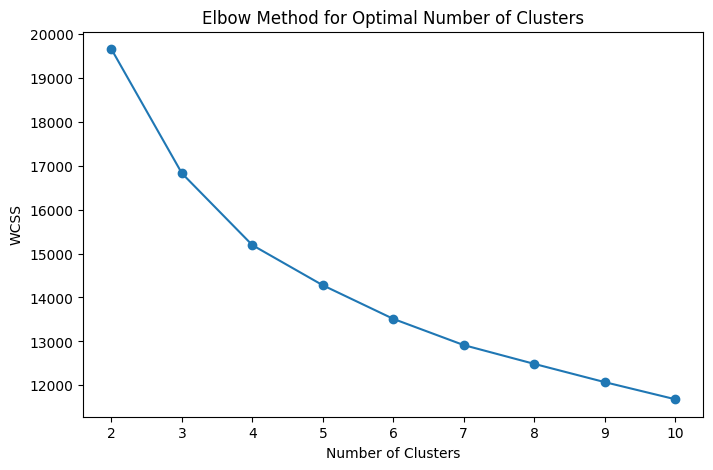

In [48]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [49]:
silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

Clusters: 2, Silhouette Score: 0.3534
Clusters: 3, Silhouette Score: 0.3078
Clusters: 4, Silhouette Score: 0.2421
Clusters: 5, Silhouette Score: 0.1520
Clusters: 6, Silhouette Score: 0.1392
Clusters: 7, Silhouette Score: 0.1389
Clusters: 8, Silhouette Score: 0.1389
Clusters: 9, Silhouette Score: 0.1302
Clusters: 10, Silhouette Score: 0.1312


In [50]:
final_k = 4

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Cluster"].value_counts()

,count
Cluster,
0,940
3,537
2,426
1,118


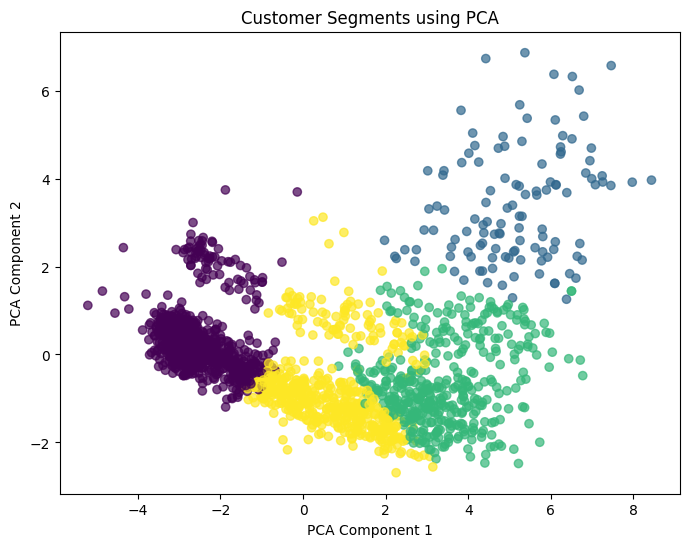

In [51]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

plt.figure(figsize=(8,6))
plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], alpha=0.7)
plt.title("Customer Segments using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [52]:
cluster_summary = df.groupby("Cluster")[
    [
        "Income",
        "Age",
        "Recency",
        "MntTotal",
        "Total_Purchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth",
        "Total_Children",
        "Avg_Spend_Per_Purchase",
        "AcceptedCmpOverall"
    ]
].mean().round(2)

cluster_summary

,Income,Age,Recency,MntTotal,Total_Purchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Children,Avg_Spend_Per_Purchase,AcceptedCmpOverall
Cluster,,,,,,,,,,,,
0,34482.19,48.49,48.99,81.64,5.89,2.13,0.56,3.20,6.49,1.27,10.22,0.09
1,80570.43,49.75,48.82,1501.55,19.93,5.64,6.16,8.14,3.55,0.28,75.81,2.51
2,74516.23,53.03,50.06,1307.49,19.54,5.20,5.98,8.36,3.01,0.27,65.91,0.30
3,57347.25,54.50,47.77,611.74,17.11,6.40,2.87,7.84,5.57,1.09,33.28,0.20


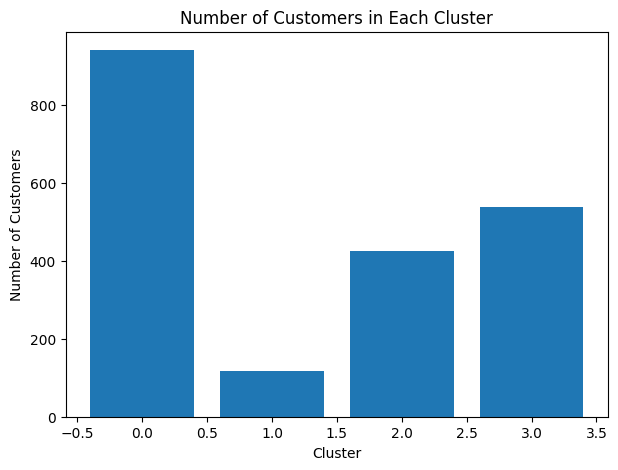

In [53]:
cluster_size = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(cluster_size.index, cluster_size.values)
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

In [54]:
segment_names = {
    0: "Budget-Conscious Customers",
    1: "Premium Loyal Customers",
    2: "Occasional Buyers",
    3: "Campaign Responsive Customers"
}

df["Segment_Name"] = df["Cluster"].map(segment_names)

df[["Cluster", "Segment_Name"]].head()

,Cluster,Segment_Name
0,2,Occasional Buyers
1,0,Budget-Conscious Customers
2,3,Campaign Responsive Customers
3,0,Budget-Conscious Customers
4,3,Campaign Responsive Customers


In [55]:
segment_summary = df.groupby("Segment_Name")[
    [
        "Income",
        "Age",
        "Recency",
        "MntTotal",
        "Total_Purchases",
        "Avg_Spend_Per_Purchase",
        "AcceptedCmpOverall"
    ]
].mean().round(2)

segment_summary

,Income,Age,Recency,MntTotal,Total_Purchases,Avg_Spend_Per_Purchase,AcceptedCmpOverall
Segment_Name,,,,,,,
Budget-Conscious Customers,34482.19,48.49,48.99,81.64,5.89,10.22,0.09
Campaign Responsive Customers,57347.25,54.50,47.77,611.74,17.11,33.28,0.20
Occasional Buyers,74516.23,53.03,50.06,1307.49,19.54,65.91,0.30
Premium Loyal Customers,80570.43,49.75,48.82,1501.55,19.93,75.81,2.51


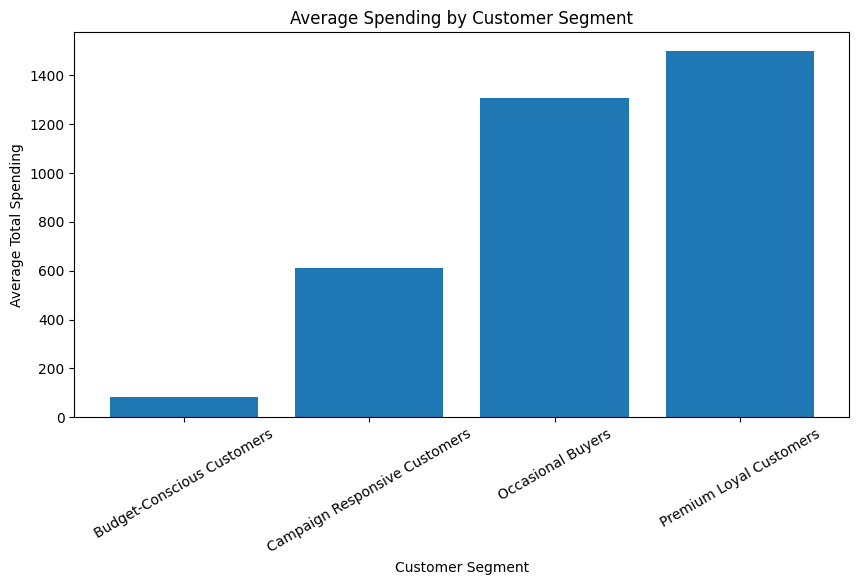

In [56]:
plt.figure(figsize=(10,5))
plt.bar(segment_summary.index, segment_summary["MntTotal"])
plt.title("Average Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=30)
plt.show()

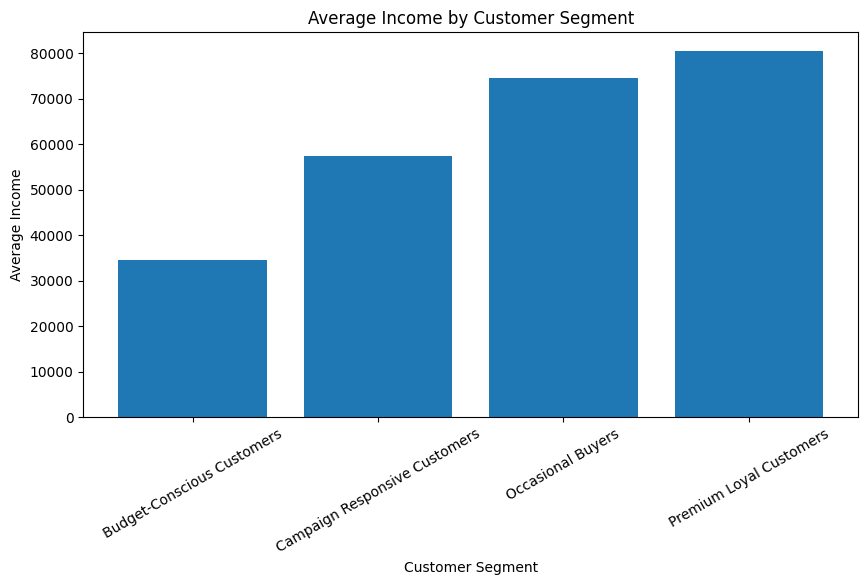

In [57]:
plt.figure(figsize=(10,5))
plt.bar(segment_summary.index, segment_summary["Income"])
plt.title("Average Income by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Income")
plt.xticks(rotation=30)
plt.show()

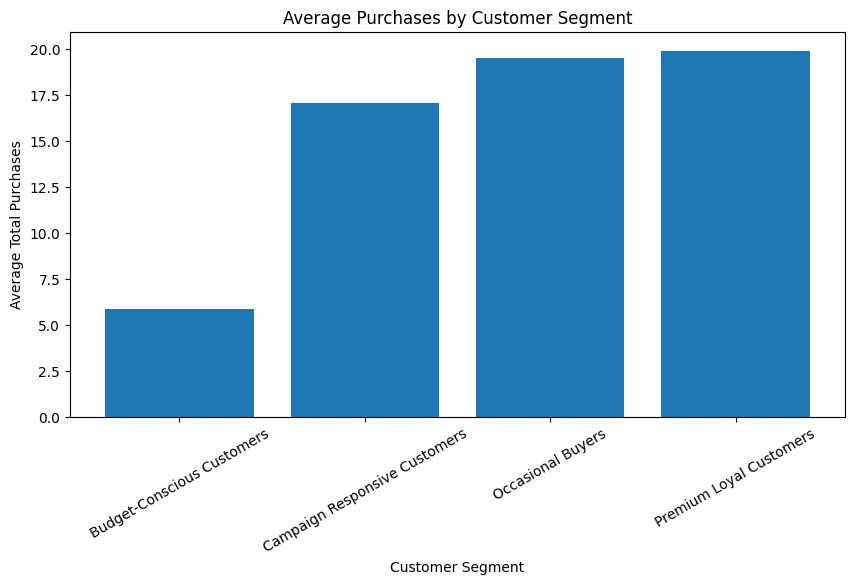

In [58]:
plt.figure(figsize=(10,5))
plt.bar(segment_summary.index, segment_summary["Total_Purchases"])
plt.title("Average Purchases by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Total Purchases")
plt.xticks(rotation=30)
plt.show()

In [59]:
hierarchical = AgglomerativeClustering(n_clusters=4)
df["Hierarchical_Cluster"] = hierarchical.fit_predict(X_scaled)

hierarchical_score = silhouette_score(X_scaled, df["Hierarchical_Cluster"])

print("Hierarchical Clustering Silhouette Score:", round(hierarchical_score, 4))

Hierarchical Clustering Silhouette Score: 0.2273


In [60]:
kmeans_score = silhouette_score(X_scaled, df["Cluster"])

print("K-Means Silhouette Score:", round(kmeans_score, 4))
print("Hierarchical Silhouette Score:", round(hierarchical_score, 4))

K-Means Silhouette Score: 0.2421
Hierarchical Silhouette Score: 0.2273


In [61]:
recommendations = {
    "Budget-Conscious Customers":
    "Offer discount coupons, combo packs, cashback, and budget-friendly product bundles.",

    "Premium Loyal Customers":
    "Provide loyalty rewards, premium memberships, early access offers, and personalized product suggestions.",

    "Occasional Buyers":
    "Use reminder campaigns, limited-time offers, and free delivery coupons to increase purchase frequency.",

    "Campaign Responsive Customers":
    "Target these customers with personalized email campaigns, festive offers, and referral programs."
}

for segment, recommendation in recommendations.items():
    print("Segment:", segment)
    print("Recommendation:", recommendation)
    print("-" * 80)

Segment: Budget-Conscious Customers
Recommendation: Offer discount coupons, combo packs, cashback, and budget-friendly product bundles.
--------------------------------------------------------------------------------
Segment: Premium Loyal Customers
Recommendation: Provide loyalty rewards, premium memberships, early access offers, and personalized product suggestions.
--------------------------------------------------------------------------------
Segment: Occasional Buyers
Recommendation: Use reminder campaigns, limited-time offers, and free delivery coupons to increase purchase frequency.
--------------------------------------------------------------------------------
Segment: Campaign Responsive Customers
Recommendation: Target these customers with personalized email campaigns, festive offers, and referral programs.
--------------------------------------------------------------------------------


In [62]:
df.to_csv("customer_segmentation_output.csv", index=False)

print("Final segmented dataset saved successfully.")

Final segmented dataset saved successfully.


In [63]:
segment_names = {
    0: "Budget-Conscious Customers",
    1: "Premium Loyal Customers",
    2: "Occasional Buyers",
    3: "Campaign Responsive Customers"
}

In [64]:
print("""
Conclusion:

This project segmented customers into meaningful groups using demographic details,
purchase behavior, spending pattern, and campaign interaction. K-Means clustering
was used after proper feature scaling, and the number of clusters was evaluated
using the Elbow Method and Silhouette Score.

The final customer segments can help the business design personalized marketing
strategies, improve customer retention, increase sales, and target customers with
more relevant offers.
""")


Conclusion:

This project segmented customers into meaningful groups using demographic details,
purchase behavior, spending pattern, and campaign interaction. K-Means clustering
was used after proper feature scaling, and the number of clusters was evaluated
using the Elbow Method and Silhouette Score.

The final customer segments can help the business design personalized marketing
strategies, improve customer retention, increase sales, and target customers with
more relevant offers.

